In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv('heart.csv')
df.sample(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
453,60,M,ASY,120,0,0,Normal,133,Y,2.0,Up,0
762,40,M,ASY,110,167,0,LVH,114,Y,2.0,Flat,1
541,76,M,NAP,104,113,0,LVH,120,N,3.5,Down,1
793,67,M,ASY,125,254,1,Normal,163,N,0.2,Flat,1
95,58,M,ASY,130,263,0,Normal,140,Y,2.0,Flat,1


In [ ]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
df['Sex'].unique()

array(['M', 'F'], dtype=object)

In [ ]:
df['ChestPainType'].unique()

array(['ATA', 'NAP', 'ASY', 'TA'], dtype=object)

In [ ]:
df['RestingECG'].unique()

array(['Normal', 'ST', 'LVH'], dtype=object)

In [ ]:
df['ExerciseAngina'].unique()

array(['N', 'Y'], dtype=object)

In [ ]:
df['ST_Slope'].unique()

array(['Up', 'Flat', 'Down'], dtype=object)

In [ ]:
df['FastingBS'].unique()

array([0, 1])

In [ ]:
target_col = "HeartDisease"

X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

In [ ]:
X

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up
...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, recall_score, precision_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, auc
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# Categorical columns and their possible categories:
cat_binary = ["Sex", "FastingBS", "ExerciseAngina"]         # these are binary-like
cat_multi = ["ChestPainType", "RestingECG", "ST_Slope"]     # multiple categories
num_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

In [ ]:
# Sanity check - keep only columns that exist in dataset
cat_binary = [c for c in cat_binary if c in X.columns]
cat_multi  = [c for c in cat_multi if c in X.columns]
num_cols   = [c for c in num_cols if c in X.columns]

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat_multi", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_multi),
        ("cat_bin", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), cat_binary),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [ ]:
clf = LogisticRegression(
    solver="liblinear",
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

In [ ]:
pipe = Pipeline([
    ("preproc", preprocessor),
    ("clf", clf)
])

In [ ]:
pipe.fit(X_train, y_train)

# -------------------------
# 6) Evaluate (default threshold=0.5)
# -------------------------
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]  # probability of positive class

print("Classification report (threshold=0.5):")
print(classification_report(y_test, y_pred, digits=4))

rec = recall_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Recall: {rec:.4f}, Precision: {prec:.4f}, F1: {f1:.4f}")

Classification report (threshold=0.5):
              precision    recall  f1-score   support

           0     0.8961    0.8415    0.8679        82
           1     0.8785    0.9216    0.8995       102

    accuracy                         0.8859       184
   macro avg     0.8873    0.8815    0.8837       184
weighted avg     0.8863    0.8859    0.8854       184

Recall: 0.9216, Precision: 0.8785, F1: 0.8995


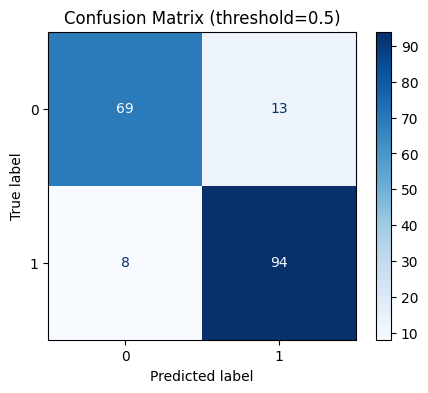

In [ ]:
# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix (threshold=0.5)")
plt.show()

Precision-Recall AUC: 0.9366


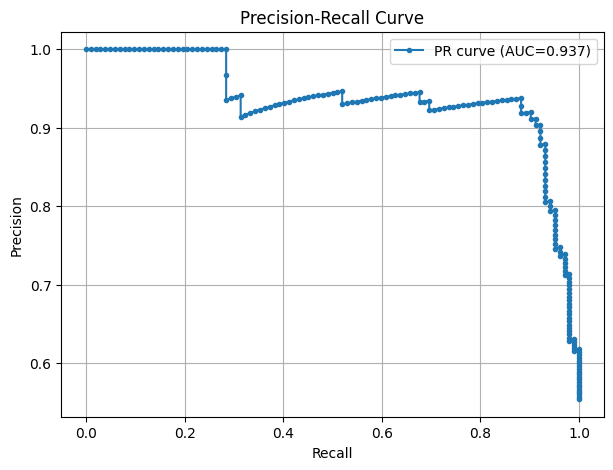

In [ ]:
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_vals, precision_vals)  # area under PR curve (recall on x-axis)
print(f"Precision-Recall AUC: {pr_auc:.4f}")

plt.figure(figsize=(7,5))
plt.plot(recall_vals, precision_vals, marker='.', label=f'PR curve (AUC={pr_auc:.3f})')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.legend()
plt.show()

Threshold 0.50 -> Recall: 0.9216, Precision: 0.8785
Threshold 0.40 -> Recall: 0.9314, Precision: 0.8559
Threshold 0.30 -> Recall: 0.9314, Precision: 0.8407
Threshold 0.20 -> Recall: 0.9510, Precision: 0.7951

Metrics with threshold = 0.3:
              precision    recall  f1-score   support

           0     0.9014    0.7805    0.8366        82
           1     0.8407    0.9314    0.8837       102

    accuracy                         0.8641       184
   macro avg     0.8711    0.8559    0.8602       184
weighted avg     0.8678    0.8641    0.8627       184



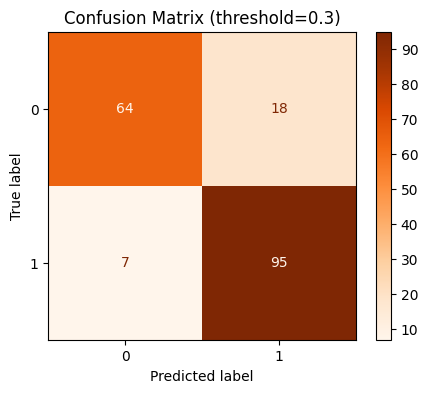

In [ ]:
# A simple table of recall/precision at some thresholds (including 0.5, 0.4, 0.3)
for thresh in [0.5, 0.4, 0.3, 0.2]:
    y_pred_thresh = (y_proba >= thresh).astype(int)
    r = recall_score(y_test, y_pred_thresh)
    p = precision_score(y_test, y_pred_thresh)
    print(f"Threshold {thresh:.2f} -> Recall: {r:.4f}, Precision: {p:.4f}")

# -------------------------
# 8) Example: pick lower threshold to increase recall (e.g., 0.3)
# -------------------------
chosen_thresh = 0.30
y_pred_low = (y_proba >= chosen_thresh).astype(int)

print(f"\nMetrics with threshold = {chosen_thresh}:")
print(classification_report(y_test, y_pred_low, digits=4))
cm_low = confusion_matrix(y_test, y_pred_low, labels=[0,1])
disp_low = ConfusionMatrixDisplay(confusion_matrix=cm_low, display_labels=[0,1])
fig, ax = plt.subplots(figsize=(5,4))
disp_low.plot(ax=ax, cmap=plt.cm.Oranges, values_format='d')
plt.title(f"Confusion Matrix (threshold={chosen_thresh})")
plt.show()

In [ ]:
# 9) Simple predict helper
# -------------------------
def predict_sample(sample_dict, threshold=0.5):
    """
    sample_dict: dict with feature names as keys, e.g.
    {
      "Age": 58, "Sex": "M", "ChestPainType": "ATA",
      "RestingBP": 140, "Cholesterol": 226, "FastingBS": 0,
      "RestingECG": "Normal", "MaxHR": 150, "ExerciseAngina": "N",
      "Oldpeak": 0.0, "ST_Slope": "Up"
    }
    """
    sample_df = pd.DataFrame([sample_dict])
    prob = pipe.predict_proba(sample_df)[0,1]
    pred = int(prob >= threshold)
    return {"prob_pos": float(prob), "pred": pred}

# Example use
example = {
    "Age": 58, "Sex": "M", "ChestPainType": "ATA",
    "RestingBP": 140, "Cholesterol": 226, "FastingBS": 0,
    "RestingECG": "Normal", "MaxHR": 150, "ExerciseAngina": "N",
    "Oldpeak": 0.0, "ST_Slope": "Up"
}
print("Example prediction:", predict_sample(example, threshold=0.5))

Example prediction: {'prob_pos': 0.05980129972002071, 'pred': 0}
